# Trader-Performance-vs-Market-Sentiment

## Part A: Data Preparation

### 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2. Load the Historical Trader Dataset

In [6]:
trader = pd.read_csv("historical_data.csv")


### 3. Display the First Five Rows

In [8]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### 4. Check the Shape of the Dataset

In [12]:
trader.shape

(211224, 16)

### 5. Display Dataset Information

In [15]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

### 6. Check Missing Values

In [18]:
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

### 7. Check Duplicate Records

In [21]:
trader.duplicated().sum()

0

### 8. Display Statistical Summary

In [24]:
trader.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


### 9. Display Column Names

In [27]:
trader.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

### 10.Inspect Timestamp Columns

In [30]:
trader[['Timestamp','Timestamp IST']].head(10)

,Timestamp,Timestamp IST
0,1.730000e+12,02-12-2024 22:50
1,1.730000e+12,02-12-2024 22:50
2,1.730000e+12,02-12-2024 22:50
3,1.730000e+12,02-12-2024 22:50
4,1.730000e+12,02-12-2024 22:50
5,1.730000e+12,02-12-2024 22:50
6,1.730000e+12,02-12-2024 22:50
7,1.730000e+12,02-12-2024 22:50
8,1.730000e+12,02-12-2024 22:50
9,1.730000e+12,02-12-2024 22:50


### 11.Convert Timestamp IST to Datetime

In [33]:
trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

### 12. Create Date Column

In [36]:
trader['Date'] = trader['Timestamp IST'].dt.date

### 13. Verify Date Column

In [39]:
trader[['Timestamp IST','Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


### 14. Daily Number of Trades

In [42]:
trades_per_day = (
    trader.groupby('Date')
    .size()
    .reset_index(name='Number_of_Trades')
)

trades_per_day.head()

,Date,Number_of_Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


### 15. Average Trade Size Per Day

In [45]:
avg_trade_size = trader.groupby('Date')['Size USD'].mean().reset_index()
avg_trade_size.head()

,Date,Size USD
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


### 16.Daily Closed PnL

### This helps analyze whether traders preferred long or short positions.

In [49]:
daily_pnl = (
    trader.groupby('Date')['Closed PnL']
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


### 17.Long vs Short Trades

In [52]:
trader['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

### 18.Long/Short Ratio by Day

In [55]:
long_short = (
    trader.groupby(['Date','Side'])
    .size()
    .reset_index(name='Trades')
)

long_short.head()

,Date,Side,Trades
0,2023-05-01,BUY,3
1,2023-12-05,BUY,7
2,2023-12-05,SELL,2
3,2023-12-14,BUY,5
4,2023-12-14,SELL,6


### 19.Long/Short Ratio by Day

In [58]:
top_traders = (
    trader.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

### 20.Plot Daily PnL

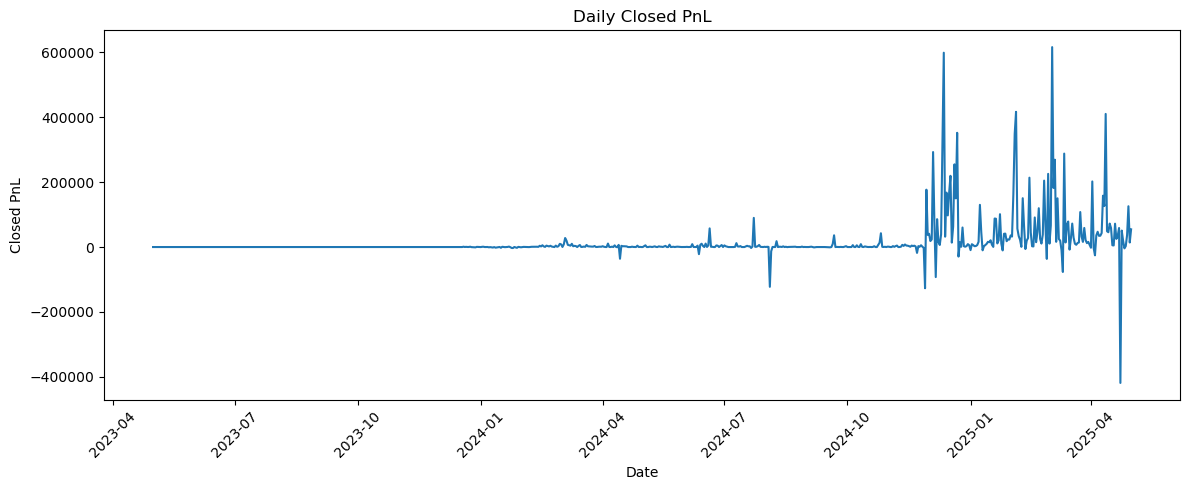

In [61]:
plt.figure(figsize=(12,5))
plt.plot(daily_pnl['Date'], daily_pnl['Closed PnL'])
plt.title("Daily Closed PnL")
plt.xlabel("Date")
plt.ylabel("Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part A: Data Preparation

### 1.Load the Fear & Greed Dataset

In [65]:
sentiment = pd.read_csv("fear_greed_index.csv")

### 2.Display the First Five Rows

In [68]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### 3.Check the Shape of the Dataset

In [71]:
sentiment.shape

(2644, 4)

### 4.Display Dataset Information

In [74]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


### 5.Check Missing Values

In [77]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

### 6.Check Duplicate Records

In [80]:
sentiment.duplicated().sum()

0

### 7.Display Statistical Summary

In [83]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


### 8.Display Column Names

In [86]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

### 9.Convert the Date Column to Datetime Format
#### The date column is converted into datetime format to enable time-based analysis and merging.

In [89]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

### 10.Create a Date Column
#### A separate Date column is created to match the trader dataset during the merge process.

In [92]:
sentiment['Date'] = sentiment['date'].dt.date

### 11.Verify the Date Column

In [95]:
sentiment[['date', 'Date']].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


### 12.Check the Distribution of Market Sentiment
#### This shows the number of records for each market sentiment category, such as Fear, Extreme Fear, Neutral, and Greed.

In [98]:
sentiment['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

### 13.Check the Date Range of the Sentiment Dataset

In [101]:
print("Start Date:", sentiment['Date'].min())
print("End Date:", sentiment['Date'].max())

Start Date: 2018-02-01
End Date: 2025-05-02


### 14.Check the Date Range of the Trader Dataset

In [104]:
print("Start Date:", trader['Date'].min())
print("End Date:", trader['Date'].max())

Start Date: 2023-05-01
End Date: 2025-05-01


# Part B: Merge & Analysis

### 1.Merge the Datasets

In [108]:
merged_data = pd.merge(trader, sentiment[['Date', 'classification']], on='Date', how='left')

### 2.Check the Merged Dataset

In [111]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


### 3.Check the Shape

In [114]:
merged_data.shape

(211224, 18)

### 4.Verify Missing Values in Classification

In [117]:
merged_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
classification      6
dtype: int64

### 5.Verify Sentiment Distribution

In [120]:
merged_data['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

### 6.Average Closed PnL by Sentiment

In [123]:
pnl_by_sentiment = (
    merged_data.groupby('classification')['Closed PnL']
    .mean()
    .reset_index()
)

pnl_by_sentiment

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


### 7.Plot Average Closed PnL

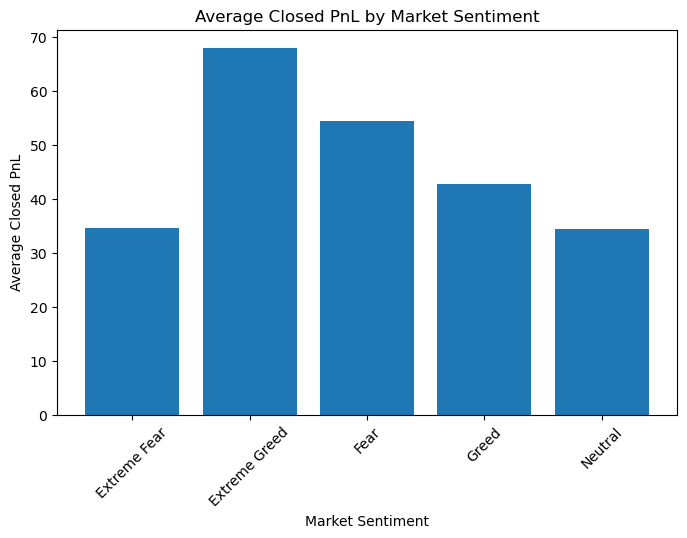

In [126]:
plt.figure(figsize=(8,5))
plt.bar(
    pnl_by_sentiment['classification'],
    pnl_by_sentiment['Closed PnL']
)
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

### 8.Trade Frequency by Market Sentiment

In [129]:
trade_frequency = merged_data.groupby('classification').size().reset_index(name='Number of Trades')
trade_frequency

,classification,Number of Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


### 9.Visualize Trade Frequency

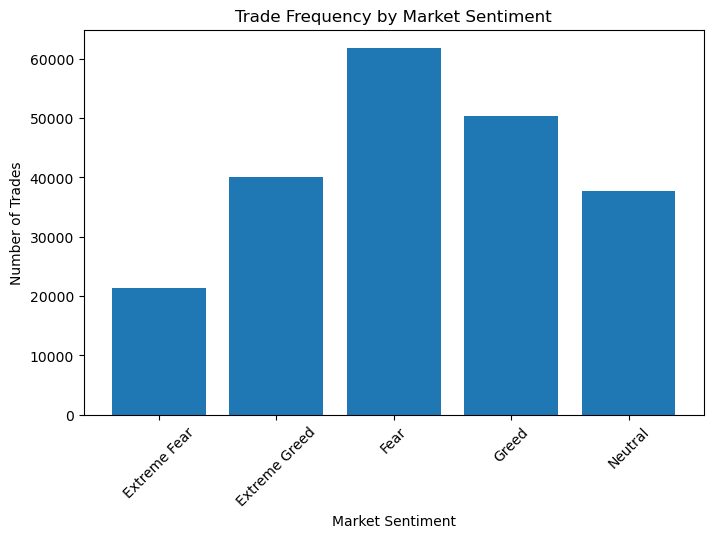

In [132]:
plt.figure(figsize=(8,5))
plt.bar(trade_frequency['classification'], trade_frequency['Number of Trades'])
plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

### 10.Average Trade Size

In [135]:
avg_trade_size = merged_data.groupby('classification')['Size USD'].mean().reset_index()
avg_trade_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


### 11.Visualize Average Trade Size

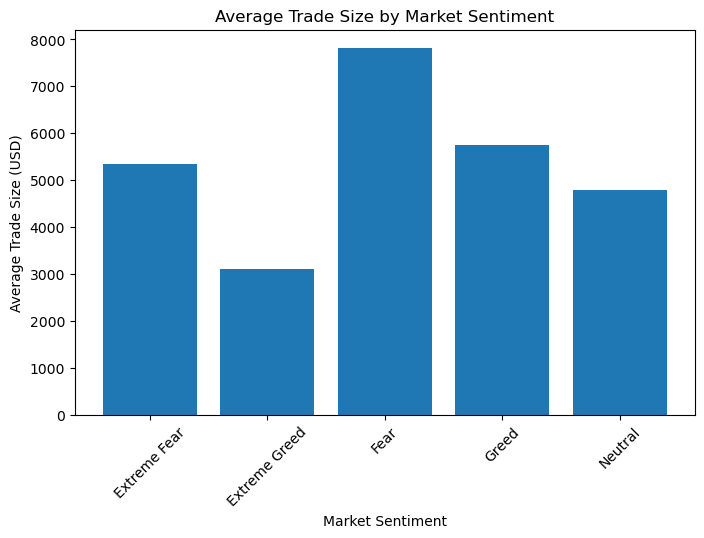

In [138]:
plt.figure(figsize=(8,5))
plt.bar(avg_trade_size['classification'], avg_trade_size['Size USD'])
plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.show()

### 12.Long vs Short Trades

In [141]:
long_short = merged_data.groupby(['classification','Side']).size().reset_index(name='Trades')
long_short

,classification,Side,Trades
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


### 13.Visualize Long vs Short Trades

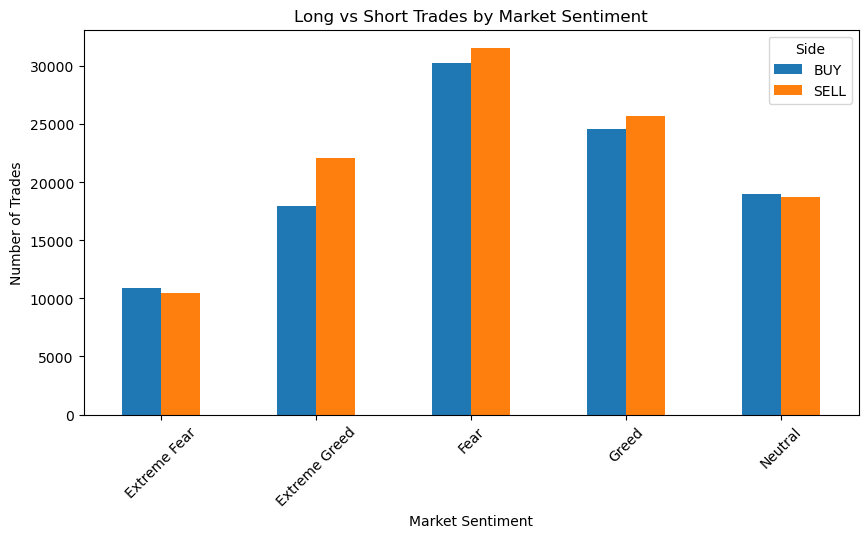

In [144]:
pivot_long_short = long_short.pivot(index='classification', columns='Side', values='Trades')

pivot_long_short.plot(kind='bar', figsize=(10,5))
plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

### 14.Calculate Win Rate

In [147]:
merged_data['Win'] = merged_data['Closed PnL'] > 0

### 15.Win Rate by Market Sentiment

In [150]:
win_rate = (
    merged_data.groupby('classification')['Win']
    .mean()
    .reset_index()
)

win_rate['Win'] = win_rate['Win'] * 100

win_rate

,classification,Win
0,Extreme Fear,37.060748
1,Extreme Greed,46.494299
2,Fear,42.076750
3,Greed,38.482794
4,Neutral,39.699093


### 16. Plot Win Rate

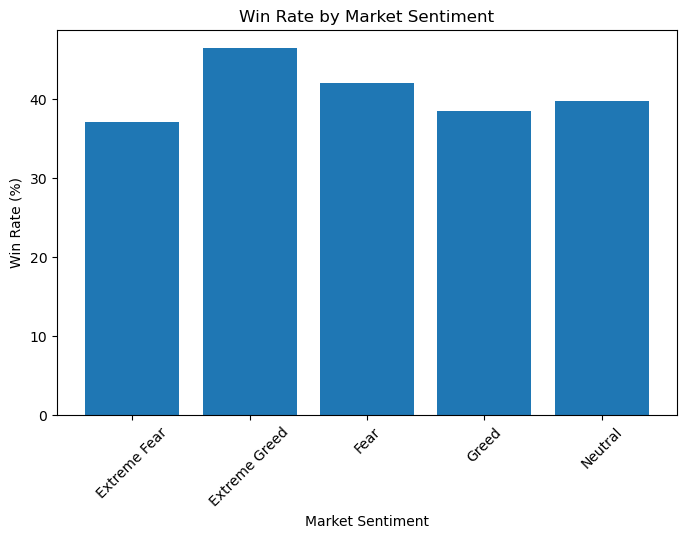

In [153]:
plt.figure(figsize=(8,5))
plt.bar(win_rate['classification'], win_rate['Win'])
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.show()

### 17 Frequent vs Infrequent Traders

In [156]:
trade_count = merged_data.groupby('Account').size().reset_index(name='Trades')

trade_count['Segment'] = np.where(
    trade_count['Trades'] >= trade_count['Trades'].median(),
    'Frequent Trader',
    'Infrequent Trader'
)

trade_count.head()

,Account,Trades,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


### 18.Top 10 Profitable Traders

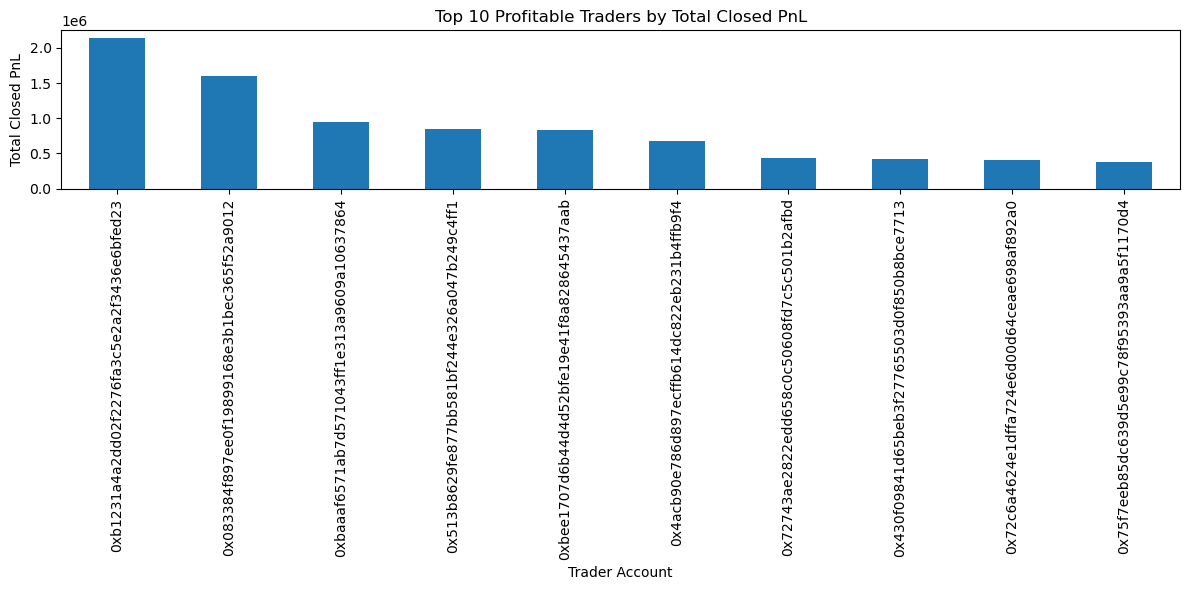

In [159]:
top_traders.plot(kind='bar', figsize=(12,6))

plt.title("Top 10 Profitable Traders by Total Closed PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Key Insights

### Insight 1: Traders achieved the highest average Closed PnL during Extreme Greed (67.89), suggesting stronger profitability under highly bullish market conditions.
### Insight 2: The largest average trade size (USD 7,816.11) was observed during Fear, indicating traders tended to commit more capital during fearful markets, possibly expecting price reversals.
### Insight 3: Neutral market sentiment resulted in comparatively lower profitability, suggesting fewer high-confidence trading opportunities during such periods.

# Strategy Recommendations

### 1.Increase exposure selectively during Extreme Greed periods while maintaining appropriate risk management, as profitability was highest under this sentiment.
### 2.Reduce trading activity during Neutral market conditions and wait for stronger market signals before entering positions.

# Conclusion

### This project analyzed the relationship between Bitcoin market sentiment and Hyperliquid trader performance. After cleaning and merging the datasets, several analyses were performed on profitability, trade frequency, trade size, win rate, and trader behavior. The findings indicate that market sentiment influences trading performance, with Extreme Greed showing the highest average profitability and Fear associated with larger trade sizes. These insights can support more informed trading and risk management decisions.

# Limitations

### 1.The historical trader dataset did not include a leverage column, so leverage-based analysis could not be performed.
### 2.The analysis is based on historical data and market sentiment labels only. Other market factors that may influence trading performance were not included.